### Imports

In [1]:
from pathlib import Path
import os
import random

os.environ.setdefault("MPLCONFIGDIR", str((Path.cwd() / ".matplotlib_cache").resolve()))
os.environ.setdefault("XDG_CACHE_HOME", str((Path.cwd() / ".cache").resolve()))
(Path.cwd() / ".matplotlib_cache").mkdir(exist_ok=True)
(Path.cwd() / ".cache").mkdir(exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
import tensorflow as tf

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE

def find_data_dir() -> Path:
    env_path = os.environ.get("CHEST_XRAY_DIR")
    candidates = []

    if env_path:
        candidates.append(Path(env_path).expanduser())

    candidates.extend(
        [
            Path("chest_xray"),
            Path.cwd() / "chest_xray",
            Path.cwd().parent / "chest_xray",
            Path.cwd() / "DeepLearning" / "chest_xray",
            Path.cwd().parent / "DeepLearning" / "chest_xray",
            Path.home() / "ComputerVisionPneumonia" / "chest_xray",
        ]
    )

    checked = []
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate in checked:
            continue
        checked.append(candidate)
        if (candidate / "train").exists() and (candidate / "test").exists():
            return candidate

    checked_paths = "\n".join(f"- {path}" for path in checked)
    raise FileNotFoundError(
        "Dataset chest_xray não encontrado. Coloque a pasta chest_xray na raiz "
        "do projeto ou dentro de DeepLearning, ou defina CHEST_XRAY_DIR com o "
        f"caminho completo. Locais verificados:\n{checked_paths}"
    )


DATA_DIR = find_data_dir()
TRAIN_DIR = DATA_DIR / "train"
TEST_DIR = DATA_DIR / "test"
AUGMENTED_DIR = DATA_DIR / "train_augmented"
IMAGE_EXTENSIONS = {".jpeg", ".jpg", ".png", ".bmp"}

CLASS_MAP = {
    "NORMAL": 0,
    "PNEUMONIA_VIRAL": 1,
    "PNEUMONIA_BACTERIAL": 2,
}
CLASS_NAMES = ["Saudavel", "Pneumonia viral", "Pneumonia bacteriana"]
NUM_CLASSES = len(CLASS_NAMES)

# Troque aqui se quiser comparar arquiteturas.
# Opcoes: "EfficientNetB0", "MobileNetV2", "ResNet50"
MODEL_NAME = "EfficientNetB0"

print("TensorFlow:", tf.__version__)
print("Modelo base:", MODEL_NAME)
print("Treino:", TRAIN_DIR.resolve())
print("Teste:", TEST_DIR.resolve())
print("Classes:", CLASS_NAMES)


TensorFlow: 2.21.0
Modelo base: EfficientNetB0
Treino: /Users/antonio/ComputerVisionPneumonia/chest_xray/train
Teste: /Users/antonio/ComputerVisionPneumonia/chest_xray/test
Classes: ['Saudavel', 'Pneumonia viral', 'Pneumonia bacteriana']


### Transformações e Carregamento de Dados

In [2]:
def label_from_folder(folder_name: str) -> int:
    try:
        return CLASS_MAP[folder_name]
    except KeyError as exc:
        raise ValueError(f"Classe desconhecida: {folder_name}") from exc


def class_name_from_label(label: int) -> str:
    return CLASS_NAMES[int(label)]


def list_images(directory: Path):
    return sorted(
        path
        for path in directory.rglob("*")
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
    )


def build_original_dataframe(split_dir: Path) -> pd.DataFrame:
    rows = []
    for class_dir in sorted(path for path in split_dir.iterdir() if path.is_dir()):
        label = label_from_folder(class_dir.name)
        for image_path in list_images(class_dir):
            rows.append(
                {
                    "path": str(image_path),
                    "label": label,
                    "class_name": class_name_from_label(label),
                    "subclass": class_dir.name,
                    "source_type": "original",
                    "source_path": str(image_path),
                }
            )
    return pd.DataFrame(rows)


original_train_df = build_original_dataframe(TRAIN_DIR)
test_df = build_original_dataframe(TEST_DIR)

display(
    original_train_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .rename_axis("classe")
    .reset_index(name="quantidade_treino_original")
)
display(
    test_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .rename_axis("classe")
    .reset_index(name="quantidade_teste")
)


,classe,quantidade_treino_original
0,Saudavel,1349
1,Pneumonia viral,1345
2,Pneumonia bacteriana,2538


,classe,quantidade_teste
0,Saudavel,234
1,Pneumonia viral,148
2,Pneumonia bacteriana,242


### Separação entre Treino e Validação

In [3]:
train_base_df, val_df = train_test_split(
    original_train_df,
    test_size=0.20,
    random_state=SEED,
    stratify=original_train_df["label"],
)

train_base_df = train_base_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)

train_source_paths = set(train_base_df["source_path"])
augmented_manifest = AUGMENTED_DIR / "manifest.csv"

if augmented_manifest.exists():
    aug_df = pd.read_csv(augmented_manifest)
    aug_df = aug_df.rename(columns={"output_path": "path"})
    aug_df["label"] = CLASS_MAP["NORMAL"]
    aug_df["class_name"] = class_name_from_label(CLASS_MAP["NORMAL"])
    aug_df["subclass"] = "NORMAL"
    aug_df["source_type"] = "augmented"
    aug_df = aug_df[
        ["path", "label", "class_name", "subclass", "source_type", "source_path"]
    ]
    aug_df = aug_df[aug_df["source_path"].isin(train_source_paths)].reset_index(
        drop=True
    )
else:
    aug_df = pd.DataFrame(columns=train_base_df.columns)

train_df = pd.concat([train_base_df, aug_df], ignore_index=True)

print(f"Treino original apos split: {len(train_base_df)}")
print(f"Validacao original: {len(val_df)}")
print(f"Augmentacoes NORMAL usadas no treino: {len(aug_df)}")
print(f"Treino final: {len(train_df)}")

display(
    train_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .rename_axis("classe")
    .reset_index(name="quantidade_treino")
)
display(
    val_df["class_name"]
    .value_counts()
    .reindex(CLASS_NAMES)
    .rename_axis("classe")
    .reset_index(name="quantidade_validacao")
)


Treino original apos split: 4185
Validacao original: 1047
Augmentacoes NORMAL usadas no treino: 0
Treino final: 4185


,classe,quantidade_treino
0,Saudavel,1079
1,Pneumonia viral,1076
2,Pneumonia bacteriana,2030


,classe,quantidade_validacao
0,Saudavel,270
1,Pneumonia viral,269
2,Pneumonia bacteriana,508


### Cálculo de Pesos das Classes

In [4]:
classes = np.arange(NUM_CLASSES)
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].to_numpy(),
)
class_weight = {
    int(class_id): float(weight) for class_id, weight in zip(classes, weights)
}
class_weight


{0: 1.2928637627432809, 1: 1.296468401486989, 2: 0.687192118226601}

### Pipeline tf.data

In [5]:
def load_and_resize(path, label):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)
    label = tf.cast(label, tf.int32)
    return image, label


def make_dataset(dataframe: pd.DataFrame, training: bool) -> tf.data.Dataset:
    paths = dataframe["path"].astype(str).to_numpy()
    labels = dataframe["label"].astype("int32").to_numpy()
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        dataset = dataset.shuffle(
            buffer_size=len(dataframe), seed=SEED, reshuffle_each_iteration=True
        )
    dataset = dataset.map(load_and_resize, num_parallel_calls=AUTOTUNE)
    dataset = dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return dataset


train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)
test_ds = make_dataset(test_df, training=False)

train_ds


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>

### Construção do Modelo Transfer Learning

In [6]:
def get_application(model_name: str):
    if model_name == "EfficientNetB0":
        return (
            tf.keras.applications.EfficientNetB0,
            tf.keras.applications.efficientnet.preprocess_input,
        )
    if model_name == "MobileNetV2":
        return (
            tf.keras.applications.MobileNetV2,
            tf.keras.applications.mobilenet_v2.preprocess_input,
        )
    if model_name == "ResNet50":
        return (
            tf.keras.applications.ResNet50,
            tf.keras.applications.resnet50.preprocess_input,
        )
    raise ValueError(f"Modelo nao suportado: {model_name}")


def make_augmentation():
    layers = [
        tf.keras.layers.RandomFlip("horizontal"),
        tf.keras.layers.RandomRotation(0.04),
        tf.keras.layers.RandomZoom(0.08),
        tf.keras.layers.RandomContrast(0.12),
    ]
    if hasattr(tf.keras.layers, "RandomBrightness"):
        try:
            layers.append(tf.keras.layers.RandomBrightness(0.08, value_range=(0, 255)))
        except TypeError:
            layers.append(tf.keras.layers.RandomBrightness(0.08))
    return tf.keras.Sequential(layers, name="augmentacao_treino")


def build_transfer_model(model_name: str):
    Application, preprocess_input = get_application(model_name)

    base_model = Application(
        include_top=False,
        weights="imagenet",
        input_shape=(*IMG_SIZE, 3),
    )
    base_model.trainable = False

    inputs = tf.keras.Input(shape=(*IMG_SIZE, 3))
    x = make_augmentation()(inputs)
    x = preprocess_input(x)
    x = base_model(x, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.35)(x)
    x = tf.keras.layers.Dense(128, activation="relu")(x)
    x = tf.keras.layers.Dropout(0.25)(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = tf.keras.Model(inputs, outputs, name=f"{model_name}_pneumonia_multiclasse")
    return model, base_model


model, base_model = build_transfer_model(MODEL_NAME)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

model.summary()


Model: "EfficientNetB0_pneumonia_multiclasse"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentacao_treino (Sequential) │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,219,046 (16.09 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 4,052,131 (15.46 MB)

### Execução do Treinamento

In [7]:
callbacks_head = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_transfer_head.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=4,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-6,
    ),
]

history_head = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks_head,
)


Epoch 1/15


/Users/antonio/VisaoComputacional/.venv/lib/python3.13/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


131/131 ━━━━━━━━━━━━━━━━━━━━ 151s 1s/step - accuracy: 0.6638 - loss: 0.8682 - val_accuracy: 0.7459 - val_loss: 0.6215 - learning_rate: 0.0010
Epoch 2/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 92s 697ms/step - accuracy: 0.7137 - loss: 0.6750 - val_accuracy: 0.7221 - val_loss: 0.5839 - learning_rate: 0.0010
Epoch 3/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 85s 647ms/step - accuracy: 0.7398 - loss: 0.5956 - val_accuracy: 0.7096 - val_loss: 0.5872 - learning_rate: 0.0010
Epoch 4/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 86s 649ms/step - accuracy: 0.7462 - loss: 0.5574 - val_accuracy: 0.6428 - val_loss: 0.6791 - learning_rate: 0.0010
Epoch 5/15
131/131 ━━━━━━━━━━━━━━━━━━━━ 87s 662ms/step - accuracy: 0.7620 - loss: 0.5119 - val_accuracy: 0.6829 - val_loss: 0.6216 - learning_rate: 3.0000e-04


### Fine-tuning

In [8]:
base_model.trainable = True

# Mantem as primeiras camadas congeladas e ajusta so o final da rede.
fine_tune_at = int(len(base_model.layers) * 0.70)
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# BatchNormalization costuma ficar mais estavel congelada durante fine-tuning.
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

callbacks_finetune = [
    tf.keras.callbacks.ModelCheckpoint(
        "best_transfer_finetuned.keras",
        monitor="val_accuracy",
        mode="max",
        save_best_only=True,
    ),
    tf.keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        mode="max",
        patience=5,
        restore_best_weights=True,
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.3,
        patience=2,
        min_lr=1e-7,
    ),
]

history_finetune = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks_finetune,
)


Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 127s 815ms/step - accuracy: 0.7166 - loss: 0.6672 - val_accuracy: 0.7498 - val_loss: 0.5512 - learning_rate: 1.0000e-05
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 105s 799ms/step - accuracy: 0.7293 - loss: 0.6531 - val_accuracy: 0.7450 - val_loss: 0.5591 - learning_rate: 1.0000e-05
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 109s 828ms/step - accuracy: 0.7240 - loss: 0.6259 - val_accuracy: 0.7393 - val_loss: 0.5636 - learning_rate: 1.0000e-05
Epoch 4/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 106s 803ms/step - accuracy: 0.7355 - loss: 0.6295 - val_accuracy: 0.7240 - val_loss: 0.6090 - learning_rate: 3.0000e-06
Epoch 5/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 102s 776ms/step - accuracy: 0.7197 - loss: 0.6465 - val_accuracy: 0.7163 - val_loss: 0.6254 - learning_rate: 3.0000e-06
Epoch 6/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 100s 757ms/step - accuracy: 0.7410 - loss: 0.5895 - val_accuracy: 0.7163 - val_loss: 0.6300 - learning_rate: 9.0000e-07


### Avaliação na Validação

33/33 ━━━━━━━━━━━━━━━━━━━━ 19s 508ms/step
                      precision    recall  f1-score   support

            Saudavel       0.83      0.98      0.90       270
     Pneumonia viral       0.57      0.67      0.61       269
Pneumonia bacteriana       0.82      0.67      0.74       508

            accuracy                           0.75      1047
           macro avg       0.74      0.77      0.75      1047
        weighted avg       0.76      0.75      0.75      1047



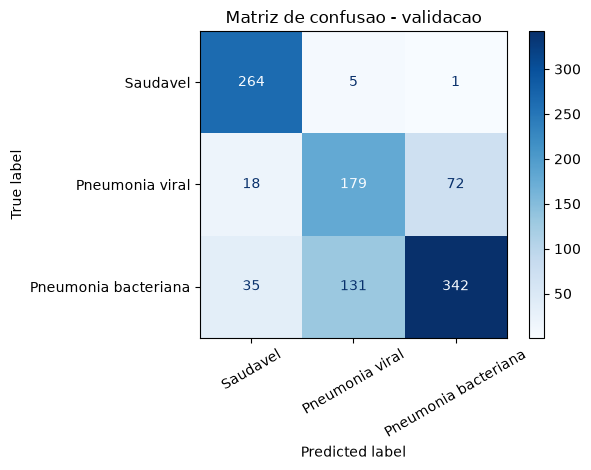

In [9]:
def predict_probabilities(model, dataset):
    return model.predict(dataset)


def predict_classes(model, dataset):
    probabilities = predict_probabilities(model, dataset)
    return probabilities, np.argmax(probabilities, axis=1)


val_true = val_df["label"].to_numpy()
val_prob, val_pred = predict_classes(model, val_ds)

print(classification_report(val_true, val_pred, target_names=CLASS_NAMES))

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(
        val_true, val_pred, labels=np.arange(NUM_CLASSES)
    ),
    display_labels=CLASS_NAMES,
).plot(cmap="Blues", values_format="d", xticks_rotation=30)
plt.title("Matriz de confusao - validacao")
plt.tight_layout()
plt.show()


### Inferência no Conjunto de Teste e Métricas Principais

20/20 ━━━━━━━━━━━━━━━━━━━━ 9s 421ms/step
AUC macro OvR teste: 0.9196027816897593

Relatorio no teste
                      precision    recall  f1-score   support

            Saudavel       0.90      0.63      0.74       234
     Pneumonia viral       0.53      0.78      0.63       148
Pneumonia bacteriana       0.86      0.86      0.86       242

            accuracy                           0.75       624
           macro avg       0.76      0.76      0.74       624
        weighted avg       0.79      0.75      0.76       624



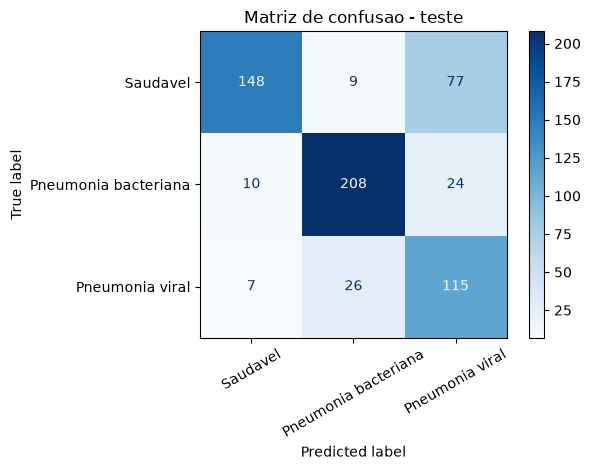

In [10]:
test_true = test_df["label"].to_numpy()
test_prob, test_pred = predict_classes(model, test_ds)

try:
    print(
        "AUC macro OvR teste:",
        roc_auc_score(test_true, test_prob, multi_class="ovr", average="macro"),
    )
except ValueError as exc:
    print("AUC macro OvR nao calculada:", exc)

print("\nRelatorio no teste")
print(classification_report(test_true, test_pred, target_names=CLASS_NAMES))

# Ordem apenas para visualizacao: bacteriana no meio da matriz.
plot_order = [
    CLASS_MAP["NORMAL"],
    CLASS_MAP["PNEUMONIA_BACTERIAL"],
    CLASS_MAP["PNEUMONIA_VIRAL"],
]
plot_labels = [class_name_from_label(label) for label in plot_order]

ConfusionMatrixDisplay(
    confusion_matrix=confusion_matrix(test_true, test_pred, labels=plot_order),
    display_labels=plot_labels,
).plot(cmap="Blues", values_format="d", xticks_rotation=30)
plt.title("Matriz de confusao - teste")
plt.tight_layout()
plt.show()


### Inspeção Visual das Previsões

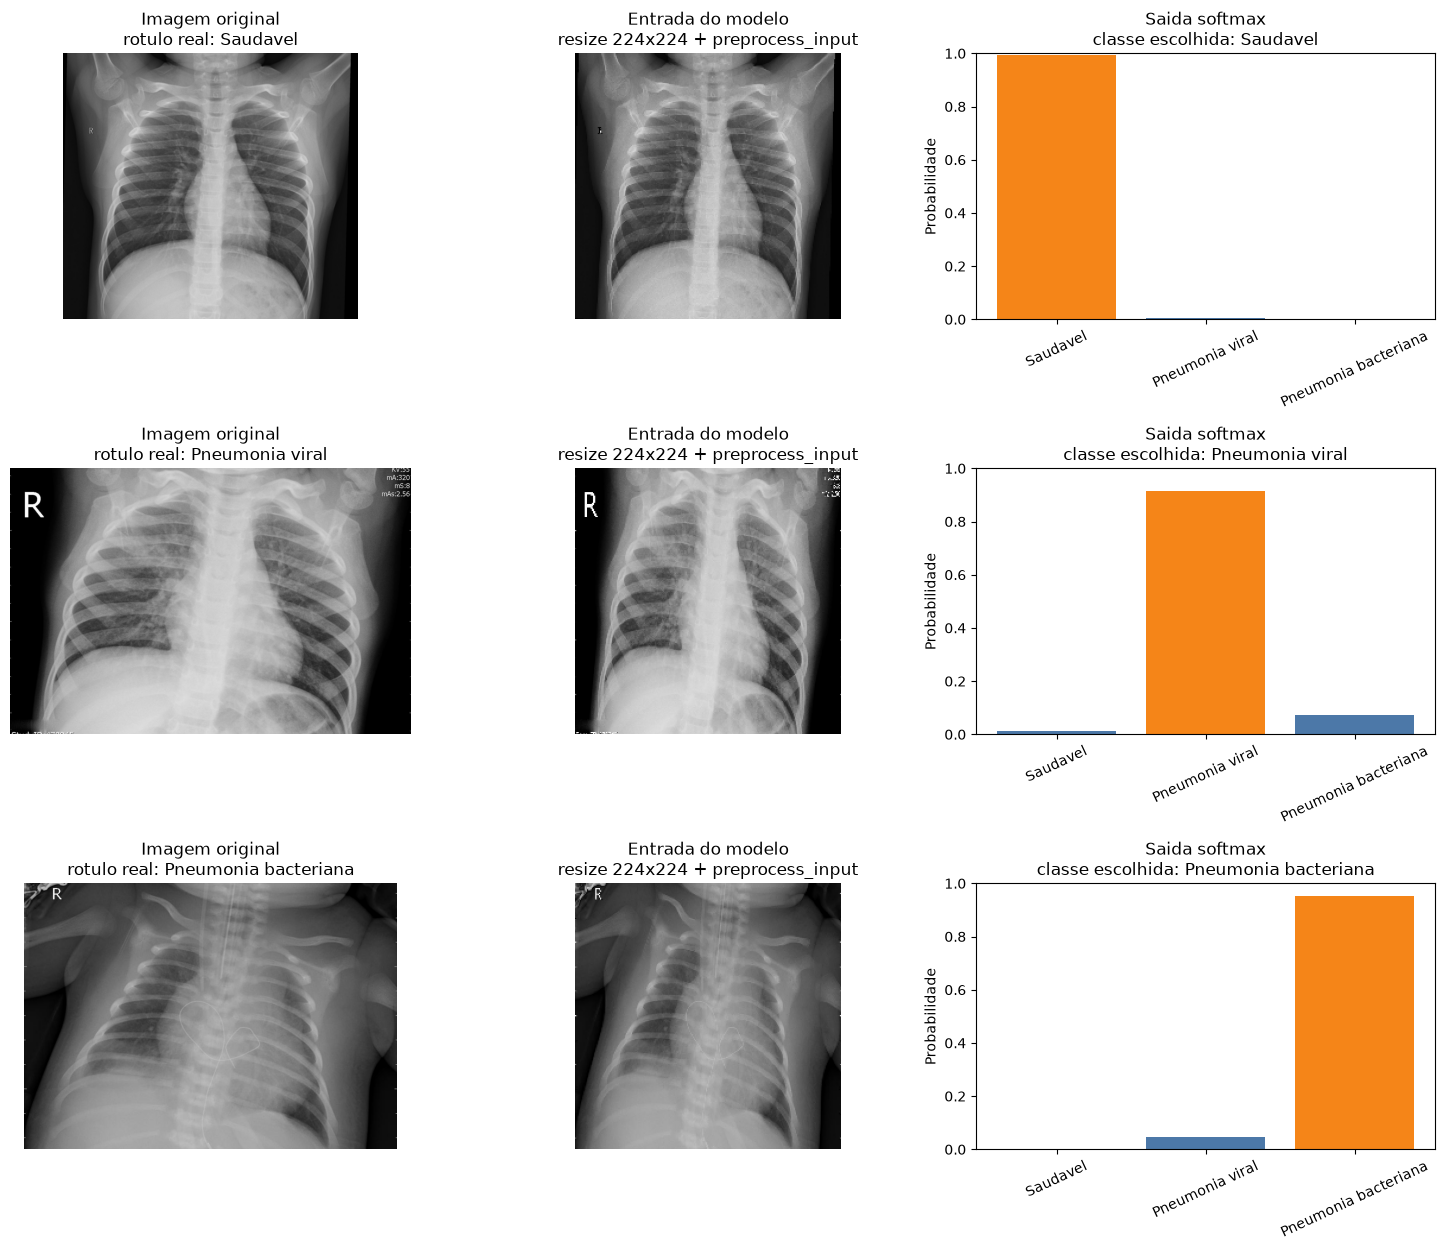

In [11]:
def load_image_for_display(path):
    image = tf.io.read_file(path)
    image = tf.io.decode_image(image, channels=3, expand_animations=False)
    image.set_shape([None, None, 3])
    image = tf.cast(image, tf.float32) / 255.0
    return image


results_df = test_df.copy().reset_index(drop=True)
results_df["true_label"] = test_true
results_df["pred_label"] = test_pred
results_df["pred_name"] = [class_name_from_label(label) for label in test_pred]
for label, class_name in enumerate(CLASS_NAMES):
    results_df[f"prob_{class_name}"] = test_prob[:, label]

examples = []
for label, class_name in enumerate(CLASS_NAMES):
    class_rows = results_df[results_df["true_label"] == label].copy()
    correct_rows = class_rows[class_rows["pred_label"] == label].copy()

    if correct_rows.empty:
        chosen = class_rows.sort_values(f"prob_{class_name}", ascending=False).iloc[0]
    else:
        chosen = correct_rows.sort_values(f"prob_{class_name}", ascending=False).iloc[0]
    examples.append(chosen)

fig, axes = plt.subplots(len(examples), 3, figsize=(15, 4.2 * len(examples)))

for row_index, example in enumerate(examples):
    original_image = load_image_for_display(example["path"])
    model_image = tf.image.resize(original_image, IMG_SIZE)
    probabilities = test_prob[int(example.name)]
    true_name = class_name_from_label(example["true_label"])
    pred_name = class_name_from_label(example["pred_label"])

    axes[row_index, 0].imshow(original_image.numpy(), cmap="gray")
    axes[row_index, 0].set_title(f"Imagem original\nrotulo real: {true_name}")
    axes[row_index, 0].axis("off")

    axes[row_index, 1].imshow(model_image.numpy(), cmap="gray")
    axes[row_index, 1].set_title("Entrada do modelo\nresize 224x224 + preprocess_input")
    axes[row_index, 1].axis("off")

    colors = [
        "#4C78A8" if i != int(example["pred_label"]) else "#F58518"
        for i in range(NUM_CLASSES)
    ]
    axes[row_index, 2].bar(CLASS_NAMES, probabilities, color=colors)
    axes[row_index, 2].set_ylim(0, 1)
    axes[row_index, 2].set_ylabel("Probabilidade")
    axes[row_index, 2].set_title(f"Saida softmax\nclasse escolhida: {pred_name}")
    axes[row_index, 2].tick_params(axis="x", rotation=25)

plt.tight_layout()
plt.show()


### Inspeção Visual de Erros

Tipo: caso classificado errado
Arquivo: /Users/antonio/ComputerVisionPneumonia/chest_xray/test/NORMAL/NORMAL2-IM-0340-0001.jpeg
Rotulo real: Saudavel
Predicao do modelo: Pneumonia bacteriana
Maior probabilidade: 0.345
Segunda maior probabilidade: 0.343
Margem de decisao: 0.002


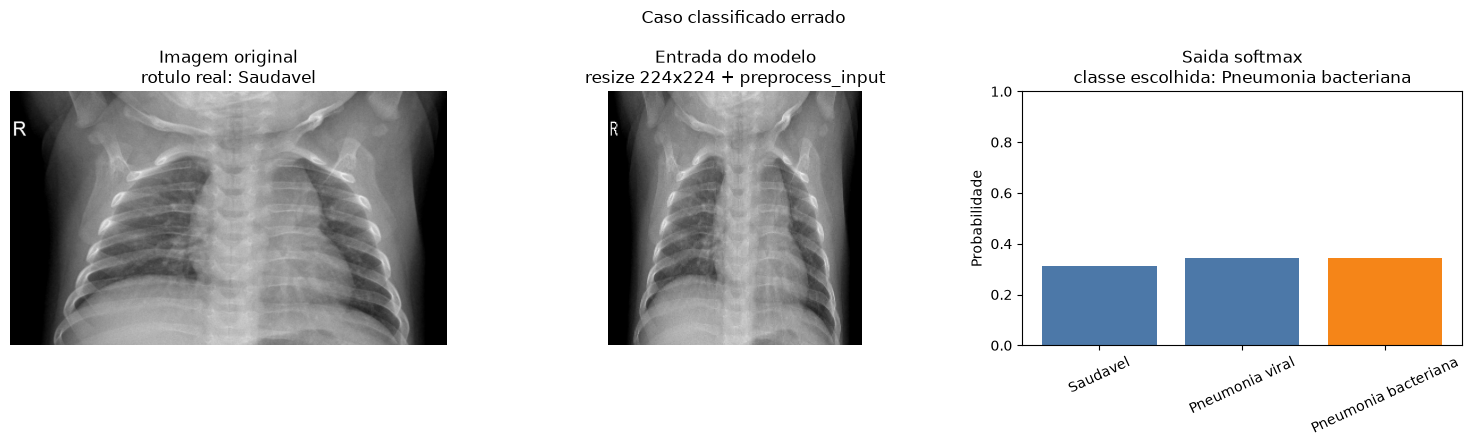

In [12]:
wrong_or_uncertain_df = test_df.copy().reset_index(drop=True)
wrong_or_uncertain_df["true_label"] = test_true
wrong_or_uncertain_df["pred_label"] = test_pred
wrong_or_uncertain_df["top_probability"] = test_prob.max(axis=1)
wrong_or_uncertain_df["second_probability"] = np.sort(test_prob, axis=1)[:, -2]
wrong_or_uncertain_df["margin"] = (
    wrong_or_uncertain_df["top_probability"]
    - wrong_or_uncertain_df["second_probability"]
)
wrong_or_uncertain_df["is_error"] = (
    wrong_or_uncertain_df["true_label"] != wrong_or_uncertain_df["pred_label"]
)

errors_df = wrong_or_uncertain_df[wrong_or_uncertain_df["is_error"]].copy()

if errors_df.empty:
    example_type = "caso de maior duvida"
    example = wrong_or_uncertain_df.sort_values("margin").iloc[0]
else:
    example_type = "caso classificado errado"
    example = errors_df.sort_values("margin").iloc[0]

example_index = int(example.name)
true_name = class_name_from_label(example["true_label"])
pred_name = class_name_from_label(example["pred_label"])
probabilities = test_prob[example_index]
original_image = load_image_for_display(example["path"])
model_image = tf.image.resize(original_image, IMG_SIZE)

print("Tipo:", example_type)
print("Arquivo:", example["path"])
print("Rotulo real:", true_name)
print("Predicao do modelo:", pred_name)
print(f"Maior probabilidade: {example['top_probability']:.3f}")
print(f"Segunda maior probabilidade: {example['second_probability']:.3f}")
print(f"Margem de decisao: {example['margin']:.3f}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].imshow(original_image.numpy(), cmap="gray")
axes[0].set_title(f"Imagem original\nrotulo real: {true_name}")
axes[0].axis("off")

axes[1].imshow(model_image.numpy(), cmap="gray")
axes[1].set_title("Entrada do modelo\nresize 224x224 + preprocess_input")
axes[1].axis("off")

colors = [
    "#4C78A8" if i != int(example["pred_label"]) else "#F58518"
    for i in range(NUM_CLASSES)
]
axes[2].bar(CLASS_NAMES, probabilities, color=colors)
axes[2].set_ylim(0, 1)
axes[2].set_ylabel("Probabilidade")
axes[2].set_title(f"Saida softmax\nclasse escolhida: {pred_name}")
axes[2].tick_params(axis="x", rotation=25)

plt.suptitle(example_type.capitalize())
plt.tight_layout()
plt.show()


### Salvar Modelo Final

In [13]:
model.save("modelo_transfer_learning_pneumonia_multiclasse.keras")

pd.DataFrame(
    {
        "label": np.arange(NUM_CLASSES),
        "class_name": CLASS_NAMES,
    }
).to_csv("modelo_transfer_learning_classes.csv", index=False)

print("Modelo salvo em modelo_transfer_learning_pneumonia_multiclasse.keras")
print("Mapa de classes salvo em modelo_transfer_learning_classes.csv")


Modelo salvo em modelo_transfer_learning_pneumonia_multiclasse.keras
Mapa de classes salvo em modelo_transfer_learning_classes.csv
